### 成績データを探索的にデータ分析
目的
- データの理解: データセットの基本的な特性、構造、分布を把握します。
- パターンの発見: データ内の関連性、トレンド、パターンを見つけ出します。
- 異常値の検出: データセット内の外れ値や異常値を特定します。
- 変数間の相関の確認: 変数間の関係性を探り、予測モデル構築のための洞察を得ます。
- 仮説生成: 分析結果を基に新たな仮説を立て、さらなる分析の方向性を定めます。


機械学習プロジェクトの初期段階でデータを深く理解するための有効な手段。

ここが弱いと、適切なデータ前処理が行えなかったり、有効な特徴量を見つけられなかったり、機械学習モデル性能に大きく直結する。

In [ ]:
# データの確認

import pandas as pd

df = pd.read_csv('./data/student-math.csv')

df.head() # 最初の5行を表示


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 探索型データ分析（EDA: Exploratory Data Analysis）
探索型データ分析（EDA: Exploratory Data Analysis）は、データセットを様々な角度から分析し、データの構造、パターン、異常値、相関関係などを理解しようとするアプローチ。EDAは、統計的手法や視覚的手法を用いてデータを探索することで、データに含まれる情報を最大限に引き出し、より深い洞察を得ることを目指す。

- 柔軟性: 事前の仮定を設けずにデータを多角的に分析します。
- 視覚的分析: ヒストグラム、散布図、箱ひげ図などのグラフィカルな方法を多用してデータを視覚化します。
- 統計的手法: 基本統計量（平均、中央値、標準偏差など）の計算や、相関係数の分析など、統計的手法を活用します。
- 考える: データから洞察を得ることを主目的とし、結果や発見が開かれた質問を導くことがあります。



スタート地点の例
- どのデータ列が最終成績(G3)に最も影響を与えるだろうか？
- そもそも男子学生と女子学生とどちらが成績がいい？
- 恋人の有無と成績の関係は？

### 数値データ・カテゴリカルデータ
データ分析において重要なのは、そのデータが**数値データ（量的データ）** なのか **カテゴリカルデータ（質的データ）**　を区別すること。
- 数値データ: 量が数値によって連続的に表現されるデータ（例. 人数や金額など)
- カテゴリカルデータ: カテゴリやグループを表す不連続のデータ

In [4]:
# データの種類(DTYPE)を確認


import pandas as pd

df = pd.read_csv('./data/student-math.csv')

df.info() # データの種類(DTYPE)を確認


# カテゴリカルデータであっても、カテゴリの種類が数値で表現されているとint64形式となる。
# また、カテゴリカルデータであっても、比較可能な数値に変換できるものがある。

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

### カラム名の日本語化

In [ ]:
# カラム名の日本語化

import pandas as pd

df = pd.read_csv('./data/student-math.csv')

columns_en = df.columns
columns_ja = [
    '学校名', '性別', '年齢', '住所', '兄弟姉妹', '住居',
    '母学歴', '父学歴', '母職業', '父職業',
    '進学理由', '保護者', '通学時間', '学習時間',
    '落第数', '奨学金', '親もち', '塾', '部活',
    '幼稚園', '大学', 'ネット', '恋人', '家族',
    '自由時間', '外出', 'アルコール', 'パリピ',
    '健康状態', '欠席日', 'G1', 'G2', 'G3'
]
df.columns = columns_ja  #日本語に差し替え

df.info() # データの種類(DTYPE)を確認

# 日本語データをCSVファイルに保存
df.to_csv('./data/student-math-ja-columns.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   学校名     395 non-null    object
 1   性別      395 non-null    object
 2   年齢      395 non-null    int64 
 3   住所      395 non-null    object
 4   兄弟姉妹    395 non-null    object
 5   住居      395 non-null    object
 6   母学歴     395 non-null    int64 
 7   父学歴     395 non-null    int64 
 8   母職業     395 non-null    object
 9   父職業     395 non-null    object
 10  進学理由    395 non-null    object
 11  保護者     395 non-null    object
 12  通学時間    395 non-null    int64 
 13  学習時間    395 non-null    int64 
 14  落第数     395 non-null    int64 
 15  奨学金     395 non-null    object
 16  親もち     395 non-null    object
 17  塾       395 non-null    object
 18  部活      395 non-null    object
 19  幼稚園     395 non-null    object
 20  大学      395 non-null    object
 21  ネット     395 non-null    object
 22  恋人      395 non-null    ob

### カテゴリカルデータの日本語化


In [ ]:
# カテゴリカルデータの日本語化

import pandas as pd

df = pd.read_csv('./data/student-math-ja-columns.csv')

df['学校名'] = df['学校名'].replace({'GP': 'GP高', 'MS': 'MS高'})
df['性別'] = df['性別'].map({'M': '男性', 'F': '女性'})
df['住所'] = df['住所'].map({'R': '郊外', 'U': '市内'})
df['兄弟姉妹'] = df['兄弟姉妹'].map({'LE3': 'なし', 'GT3': 'あり'})
df['住居'] = df['住居'].map({'A': '下宿', 'T': '同居'})
df['母職業'] = df['母職業'].map(
    {'at_home': 'なし', 'services': 'サービス', 'teacher': '教師', 'health': '医療', 'other': 'その他'})
df['父職業'] = df['父職業'].map(
    {'at_home': 'なし', 'services': 'サービス', 'teacher': '教師', 'health': '医療', 'other': 'その他'})
df['進学理由'] = df['進学理由'].map(
    {'course': '教育内容', 'home': '通いやすさ', 'reputation': '評判の良さ', 'other': 'その他'})
df['保護者'] = df['保護者'].map({'mother': '母親', 'father': '父親', 'other': 'その他'})




# 日本語データをCSVファイルに保存
df.to_csv('./data/student-math-ja-categorical.csv', index=False)


df.head()

,学校名,性別,年齢,住所,兄弟姉妹,住居,母学歴,父学歴,母職業,父職業,...,家族,自由時間,外出,アルコール,パリピ,健康状態,欠席日,G1,G2,G3
0,GP高,女性,18,市内,あり,下宿,4,4,なし,教師,...,4,3,4,1,1,3,6,5,6,6
1,GP高,女性,17,市内,あり,同居,1,1,なし,その他,...,5,3,3,1,1,3,4,5,5,6
2,GP高,女性,15,市内,なし,同居,1,1,なし,その他,...,4,3,2,2,3,3,10,7,8,10
3,GP高,女性,15,市内,あり,同居,4,2,医療,サービス,...,3,2,2,1,1,5,2,15,14,15
4,GP高,女性,16,市内,あり,同居,3,3,その他,その他,...,4,3,2,1,2,5,4,6,10,10


### カテゴリカルデータの分布的な理解
数値データは、describe()メソッドを使って、要約統計量を求めることができた。
カテゴリデータは、便利なメソッドは用意されていませんが、value_counts()を使うと、カテゴリデータの分布的な理解の助けになる。



In [ ]:
# カテゴリカルデータの割合を確認
import pandas as pd

df = pd.read_csv('./data/student-math-ja-categorical.csv')


# 性別の割合を確認
df['性別'].value_counts()


性別
女性    208
男性    187
Name: count, dtype: int64

### カテゴリカルデータの視覚的な理解
**Seaborn** はPythonのデータ可視化ライブラリであり、matplotlibの上に構築されている。主に統計グラフィックスを作成するために設計されており、美しいデフォルトスタイルとカラースキームを提供し、複雑な可視化をよりアクセスしやすくする高水準のインターフェースを持っている。


<Axes: xlabel='性別', ylabel='count'>

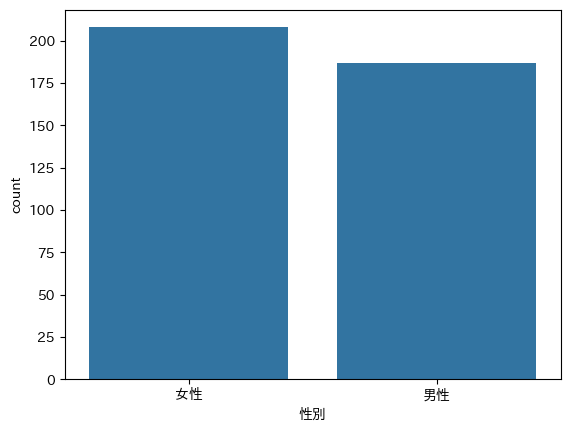

In [ ]:
# seabornを使って、カテゴリカルデータの割合を棒グラフで可視化
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')

sns.countplot(x=df['性別'])


### 高度な視覚化とデータ解析
Seabornは、美しくて情報量の高いグラフィカルな出力を生成するための高水準インタフェースを提供し、複雑な視覚化を比較的簡単に行うことができる。色彩豊かで多様なプロットスタイルや色のテーマを簡単に適用できるため、探索的データ分析に非常に役立つ。

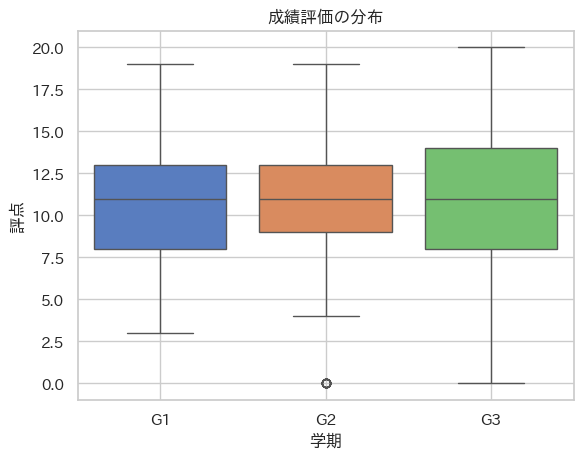

In [ ]:
# seabornを使って、箱ひげ図を描画
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')



# ボックスプロットの作成
sns.boxplot(data=[df['G1'], df['G2'], df['G3']], palette="muted")

# グリッドを表示
plt.grid(True)

# 軸のラベルの追加
plt.xlabel('学期')
plt.ylabel('評点')

# タイトルの追加
plt.title('成績評価の分布')

# 表示
plt.show()



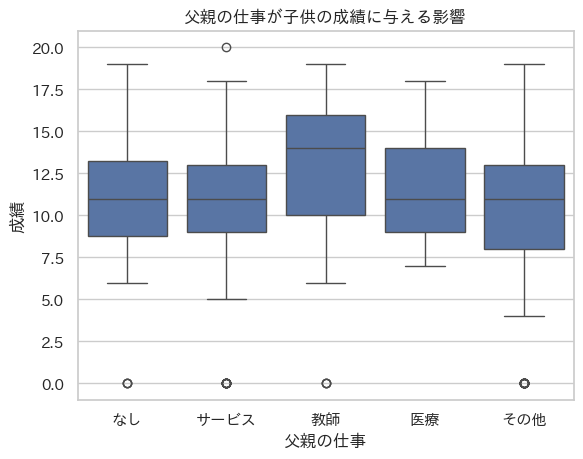

In [49]:
# seabornを使って、カテゴリーごとの箱ひげ図を描画
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')


order_by = ['なし', 'サービス', '教師', '医療', 'その他']

# ボックスプロットの作成
sns.boxplot(x=df['父職業'], y=df['G3'], order=order_by )

# 軸のラベルの追加
plt.xlabel('父親の仕事')
plt.ylabel('成績')

# タイトルの追加
plt.title('父親の仕事が子供の成績に与える影響')

# 表示
plt.show()



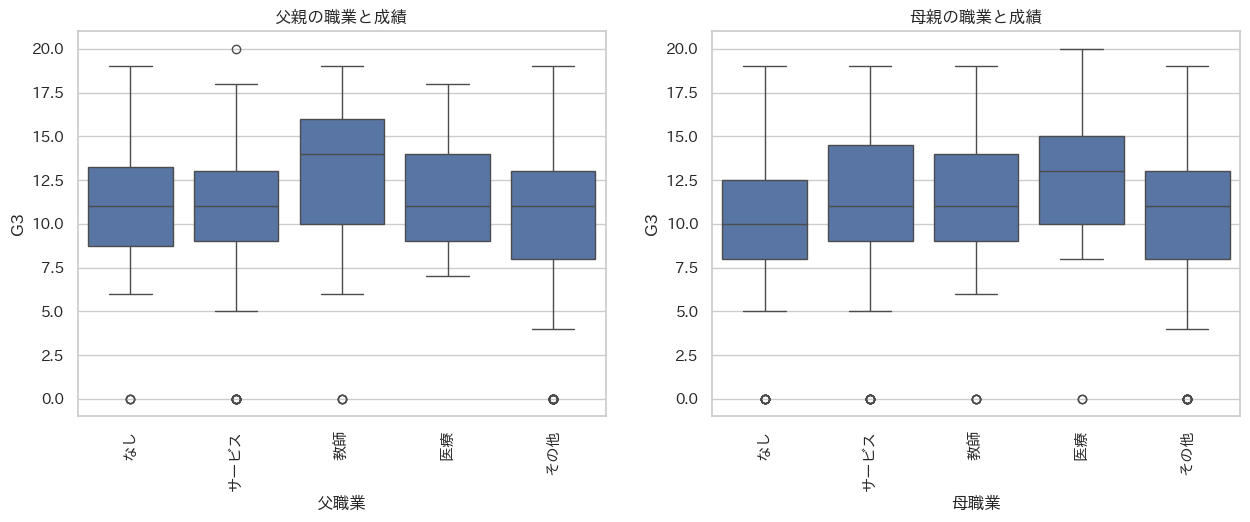

In [ ]:
# seabornを使って、複数のカテゴリーごとの箱ひげ図を描画
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')

# スタイルの適用

plt.figure(figsize=(15, 5)) # 大きさの調整
plt.subplot(1, 2, 1) # 1行2列の1番目のグラフ

order_by = ['なし', 'サービス', '教師', '医療', 'その他']

# ボックスプロットの作成
sns.boxplot(x=df['父職業'], y=df['G3'], order=order_by)

plt.xticks(rotation=90) # x軸のラベルを90度回転
plt.title('父親の職業と成績')

plt.subplot(1, 2, 2) # 1行2列の2番目のグラフ
sns.boxplot(x=df['母職業'], y=df['G3'], order=order_by)
plt.xticks(rotation=90)  # x軸のラベルを90度回転
plt.title('母親の職業と成績')

# 表示
plt.show()



### ヒストグラム


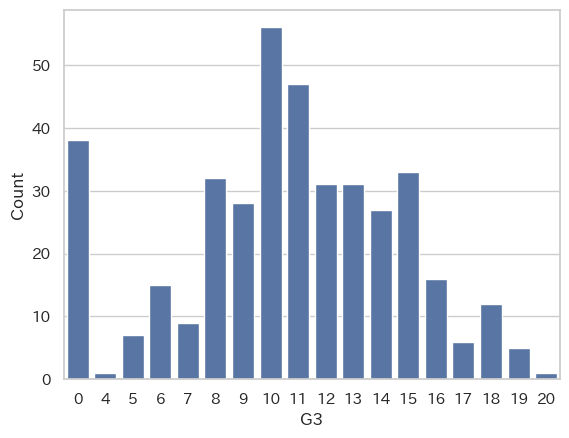

In [39]:
# seabornを使って、ヒストグラムを描画
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')


sns.countplot(x=df['G3'])
plt.xlabel('G3')
plt.ylabel('Count')
plt.show()

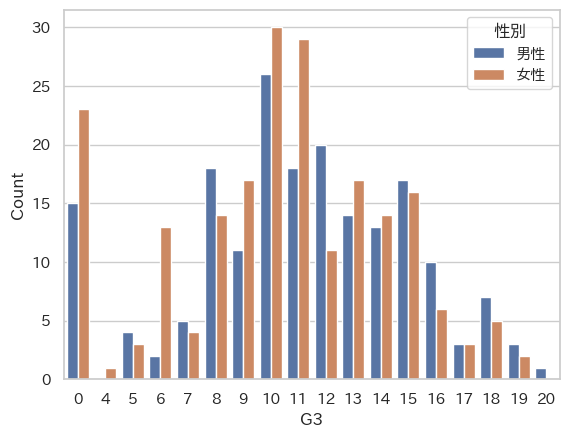

In [ ]:
# hueを使って、性別ごとにヒストグラムを描画
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')


sns.countplot(x=df['G3'], hue=df['性別'], data=df)
plt.xlabel('G3')
plt.ylabel('Count')
plt.show()

### カーネル密度推定法を使用して滑らかな曲線に補完する
カーネル密度推定（Kernel Density Estimation, KDE）は、連続する確率変数の確率密度関数（PDF）を推定するための非パラメトリックな方法であり、確率変数の分布を滑らかな形で可視化する。



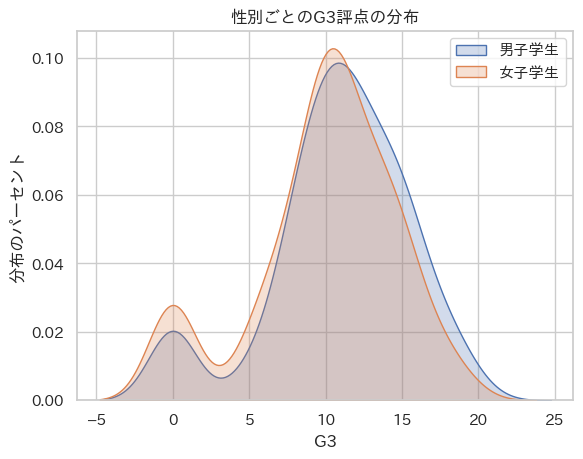

In [52]:
# カーネル密度推定を使って、成績の分布を描画

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')


sns.kdeplot(data=df[df['性別'] == '男性']['G3'], fill=True, label='男子学生')
sns.kdeplot(data=df[df['性別'] == '女性']['G3'], fill=True, label='女子学生')

plt.xlabel('G3')
plt.ylabel('分布のパーセント')
plt.title('性別ごとのG3評点の分布')
plt.legend()
plt.show()

### 散布図

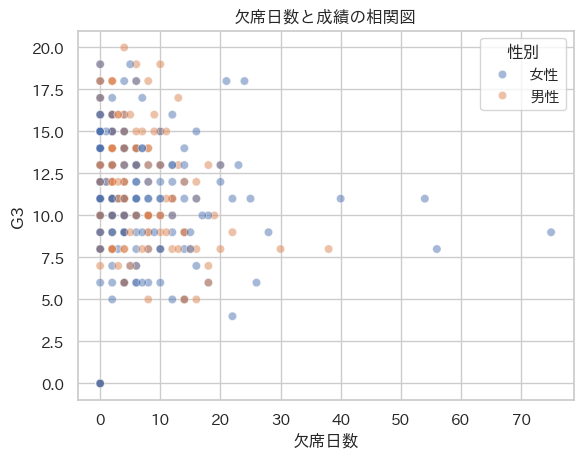

In [56]:
# 散布図を使って、欠席日数とを績の関係を描画
# hueを使って、性別ごとに散布図を描画

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')


sns.scatterplot(x=df['欠席日'], y=df['G3'], hue='性別', data=df, alpha=0.5)


plt.xlabel('欠席日数')
plt.ylabel('G3')
plt.title('欠席日数と成績の相関図')
plt.show()

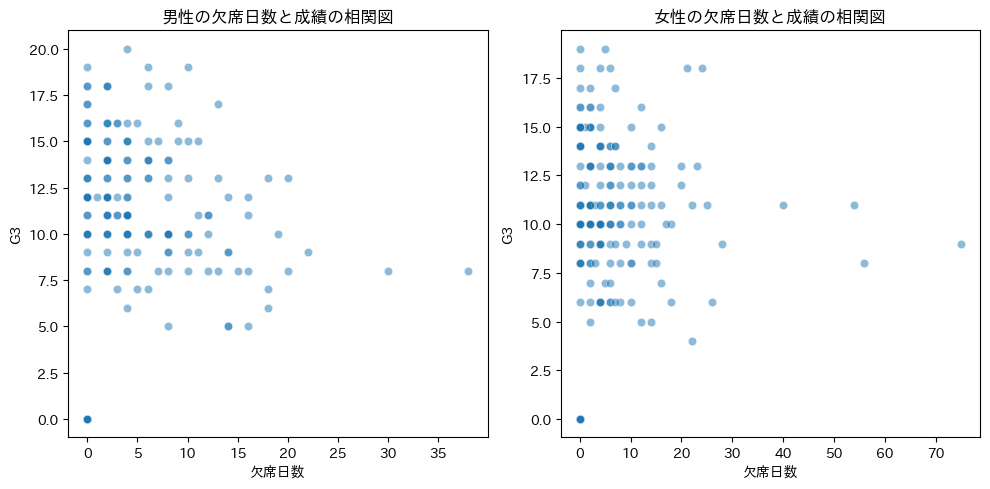

In [1]:
# 散布図を使って、欠席日数とを績の関係を描画
# 横並びで描画Ver

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')



# サブプロットの設定
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列のサブプロット

# 男性用のプロット
sns.scatterplot(ax=axes[0], x='欠席日', y='G3', data=df[df['性別'] == '男性'], alpha=0.5)
axes[0].set_title('男性の欠席日数と成績の相関図')
axes[0].set_xlabel('欠席日数')
axes[0].set_ylabel('G3')

# 女性用のプロット
sns.scatterplot(ax=axes[1], x='欠席日', y='G3', data=df[df['性別'] == '女性'], alpha=0.5)
axes[1].set_title('女性の欠席日数と成績の相関図')
axes[1].set_xlabel('欠席日数')
axes[1].set_ylabel('G3')

plt.tight_layout()
plt.show()

### グリッドパターン
グリッドパターンとは、特にデータが整数や固定の区切り値を取る場合、散布図上でポイントがグリッド状に並ぶこと。

データが特定の間隔やカテゴリに制限されていることを示し、連続的なデータとは異なるパターンを生じさせる。

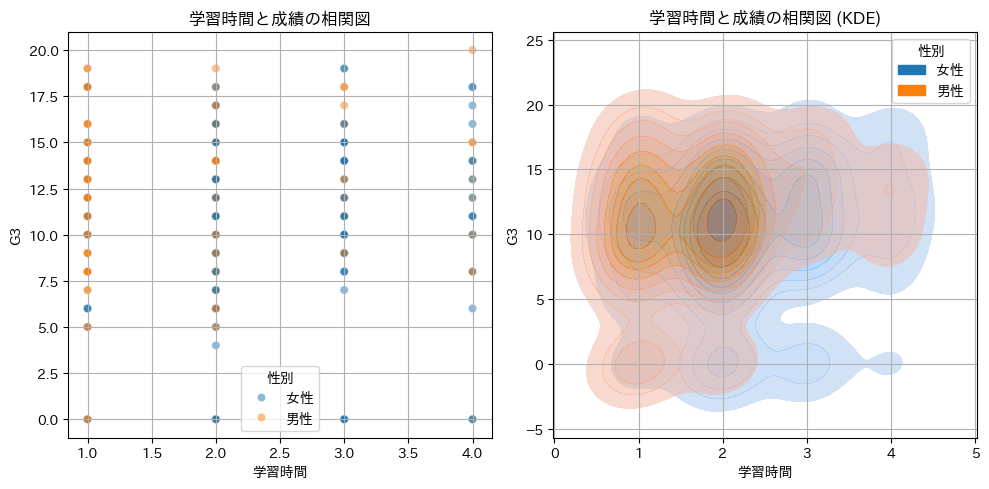

In [8]:
# グリッドパターンの例
# 学習時間と成績の相関図

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')

# サブプロットの設定
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列のサブプロット

# グリッドパターンのプロット
sns.scatterplot(ax=axes[0], x='学習時間', y='G3', hue='性別', data=df, alpha=0.5)
axes[0].grid(True)  # グリッドを表示
axes[0].set_title('学習時間と成績の相関図')
axes[0].set_xlabel('学習時間')
axes[0].set_ylabel('G3')

# カーネル密度推定(KDE)のプロット
sns.kdeplot(ax=axes[1], x='学習時間', y='G3', hue='性別', data=df, fill=True, alpha=0.5)
axes[1].grid(True)  # グリッドを表示
axes[1].set_title('学習時間と成績の相関図 (KDE)')
axes[1].set_xlabel('学習時間')
axes[1].set_ylabel('G3')

plt.tight_layout()
plt.show()

### 一度に可視化する
**pairplot()** は、複数のデータ間のペアごとに一度に可視化する ときに使う。

この関数は、数値データ間の散布図と、ヒストグラムや密度プロットを含むグリッドを作成する。また、カテゴリカル変数がある場合には、hueパラメータの使用によってデータのグループ化を行うことができる。

Text(0.5, 1.02, '成績のペアプロット')

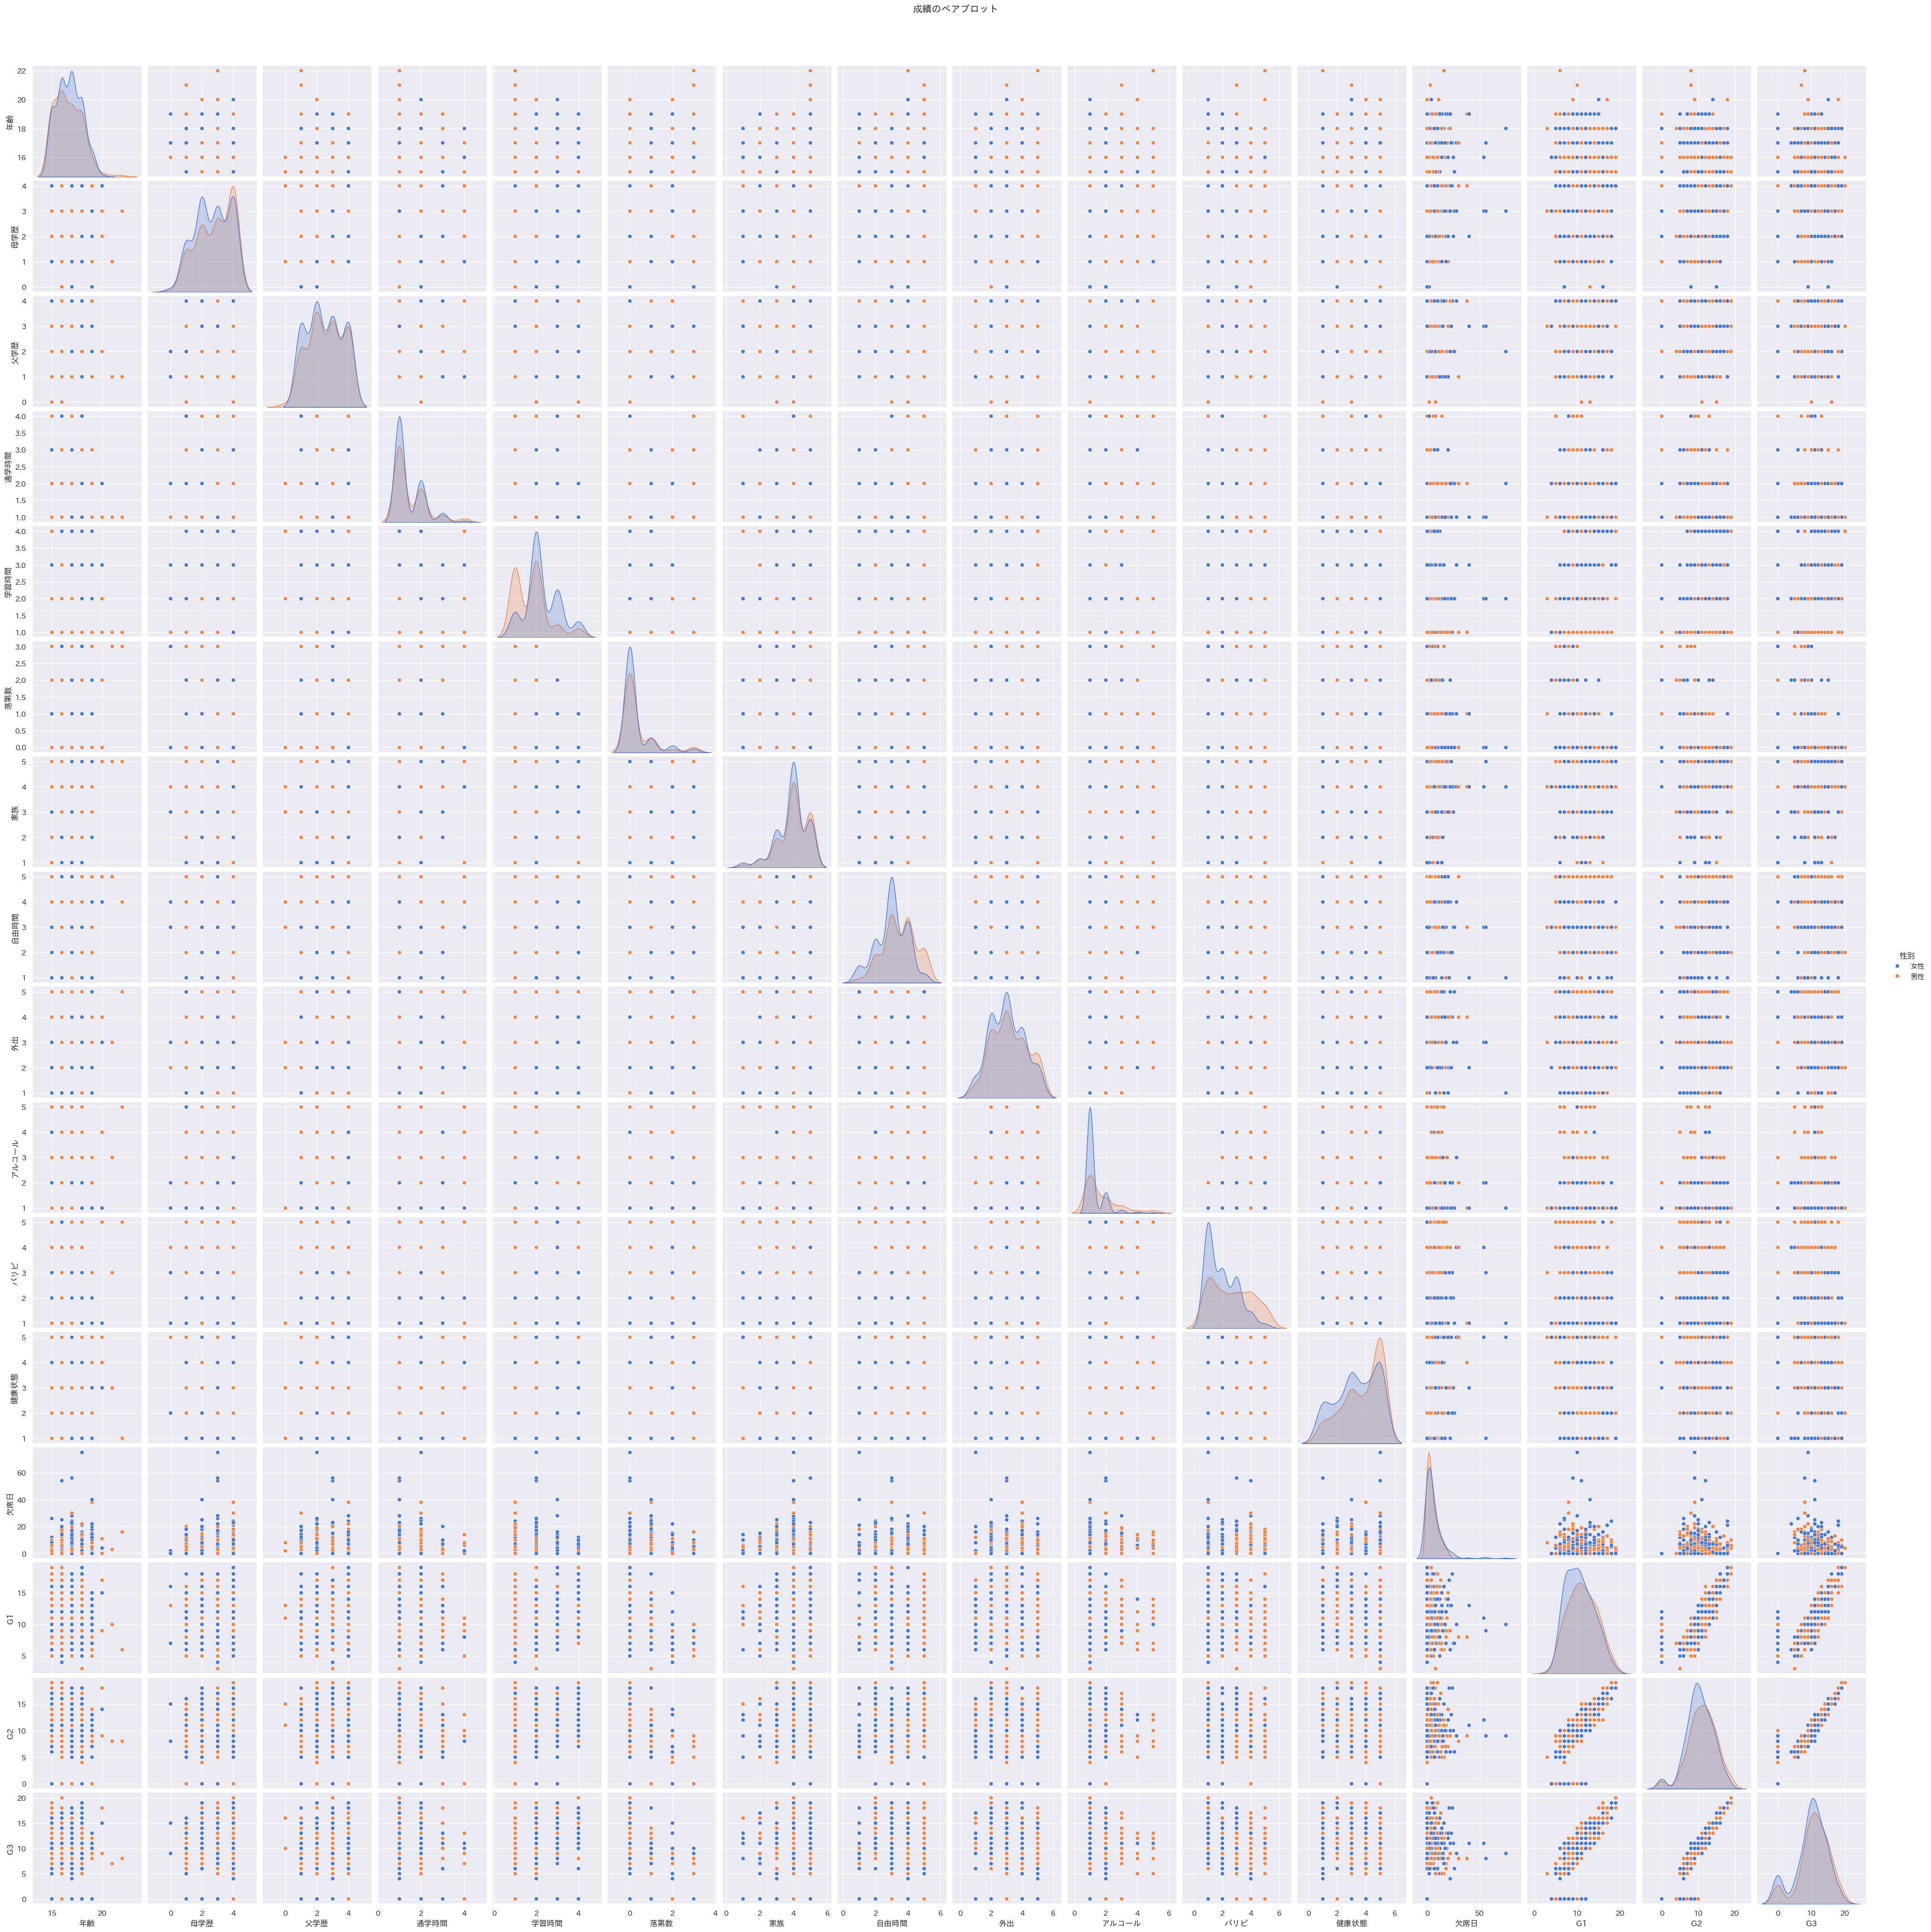

In [16]:
# pairplotの例
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')

sns.set_theme(style="darkgrid", font="IPAexGothic") # スタイルの適用

sns.pairplot(df, hue='性別', palette='muted')
plt.suptitle('成績のペアプロット', y=1.02)


Text(0.5, 1.02, '成績のペアプロット')

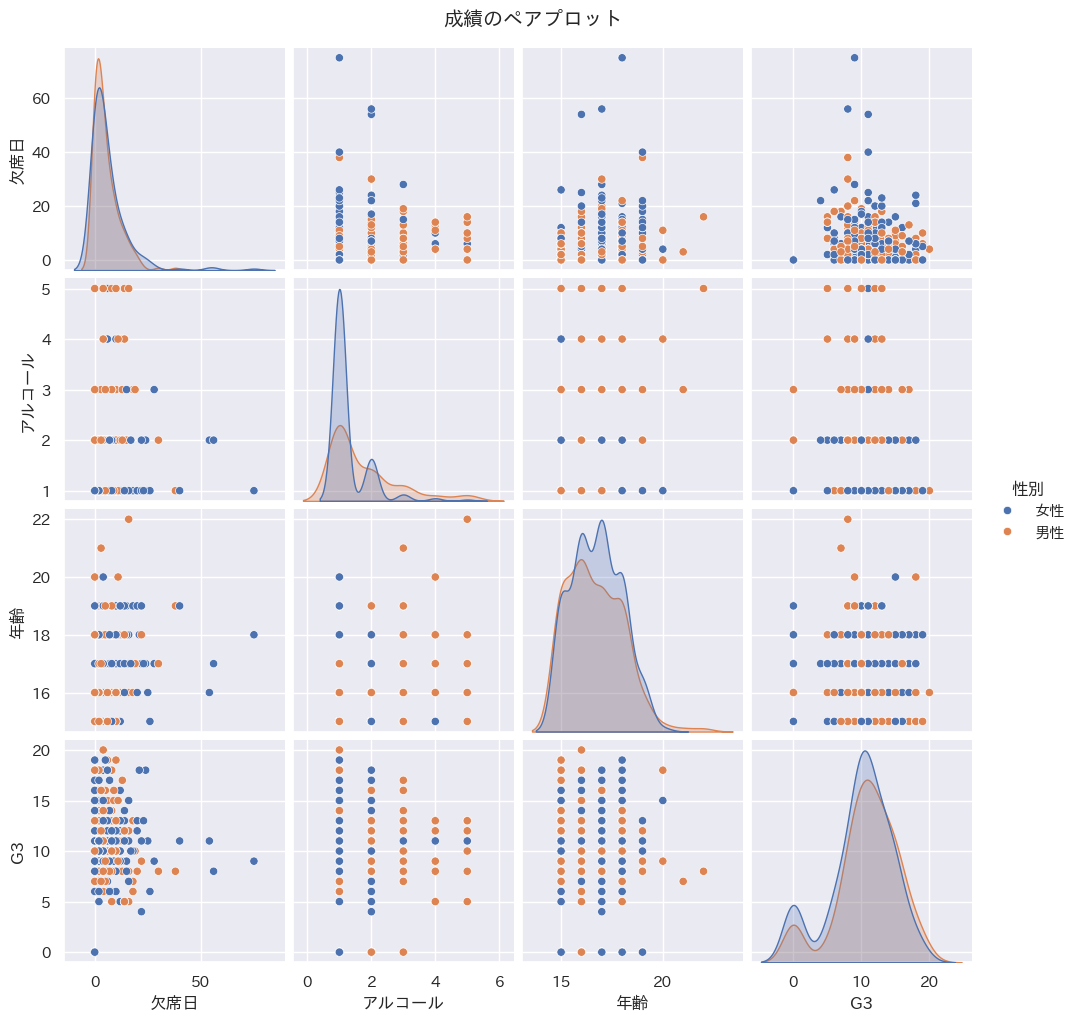

In [ ]:
# pairplotの例
# 見たいカラムに絞る
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/student-math-ja-categorical.csv')

sns.set_theme(style="darkgrid", font="IPAexGothic") # スタイルの適用

sns.pairplot(df[['欠席日', 'アルコール', '年齢', 'G3', '性別']], hue='性別')

plt.suptitle('成績のペアプロット', y=1.02)